# Insight: Cuisine popularity by Location and by Gender

**Data source:** `Cuisine_rating_clean.csv` (the cleaned dataset — see `Cuisine_rating_cleaning.ipynb`). Location has already been normalized there: casing/typo variants merged and comma-spacing standardized, so this is 8 real locations, not the original 10 raw strings.

**Columns used:** `Cuisines`, `Location`, `Gender`.

**Question:** What types of cuisines are most popular by location and by gender?

**Scope confirmed:** "Popular" is read as frequency/demand — how many diners in each group ordered each cuisine — not rating/satisfaction (that's covered by separate insights on smoking and age vs. Food/Service Rating). Both breakdowns (by Location, by Gender) are covered in this one notebook since they're two views of the same popularity question. Full 200-row cleaned dataset, no other filters.

## Assumptions

- "Popular" = count of diners who ordered a given cuisine within a group (row-wise share), not a satisfaction/rating metric.
- Location groups are the 8 cleaned location values. `Area code`/`Gender`/`Marital Status`/`Activity`/`Cuisines`/`Alcohol`/`Smoker`/`Often A S` dtypes are re-cast to `category` on load per the cleaning notebook's Decisions 5 & 6, since the CSV itself doesn't persist dtype.
- "Most popular" is reported both as a single top cuisine and alongside the runner-up, since with only 200 rows split across 7 cuisines and 8 locations, several groups have narrow or tied leads.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('Cuisine_rating_clean.csv')
df.columns = [c.strip() for c in df.columns]

category_cols = ['Location', 'Gender', 'Marital Status', 'Activity', 'Cuisines', 'Alcohol', 'Smoker', 'Often A S']
for c in category_cols:
    df[c] = df[c].astype('category')
df['Area code'] = df['Area code'].astype('category')

print(df.shape)
df.head(3)

(200, 15)


,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.5,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.0,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.0,Yes


## Cuisine popularity by Location

In [2]:
ct_loc_counts = pd.crosstab(df['Location'], df['Cuisines'])
ct_loc_pct = pd.crosstab(df['Location'], df['Cuisines'], normalize='index').round(3) * 100

print('Counts (Cuisine x Location):')
display(ct_loc_counts)
print('\nRow %% (share of each location\'s diners choosing each cuisine):')
display(ct_loc_pct.round(1))

Counts (Cuisine x Location):


Cuisines,Chinese,Filipino,French,Indian,Italian,Japanese,Seafood
Location,,,,,,,
"Cedar Hill,NY",0,0,0,2,0,0,0
"Central Park,NY",2,8,6,6,2,4,4
"China Town,NY",2,2,4,6,0,0,8
"Market City,NY",0,2,4,6,0,6,4
"Riverdale,NY",4,6,2,0,6,8,2
"St. George,NY",4,12,8,8,4,10,0
"Upper East Side,NY",10,2,6,2,4,6,0
"Upper West Side,NY",2,2,4,2,2,2,4



Row %% (share of each location's diners choosing each cuisine):


Cuisines,Chinese,Filipino,French,Indian,Italian,Japanese,Seafood
Location,,,,,,,
"Cedar Hill,NY",0.0,0.0,0.0,100.0,0.0,0.0,0.0
"Central Park,NY",6.2,25.0,18.8,18.8,6.2,12.5,12.5
"China Town,NY",9.1,9.1,18.2,27.3,0.0,0.0,36.4
"Market City,NY",0.0,9.1,18.2,27.3,0.0,27.3,18.2
"Riverdale,NY",14.3,21.4,7.1,0.0,21.4,28.6,7.1
"St. George,NY",8.7,26.1,17.4,17.4,8.7,21.7,0.0
"Upper East Side,NY",33.3,6.7,20.0,6.7,13.3,20.0,0.0
"Upper West Side,NY",11.1,11.1,22.2,11.1,11.1,11.1,22.2


In [3]:
rows = []
for loc in ct_loc_counts.index:
    row = ct_loc_counts.loc[loc].sort_values(ascending=False)
    total = row.sum()
    top_val = row.iloc[0]
    top_cuisines = row[row == top_val].index.tolist()
    runner = row.iloc[1] if len(row) > 1 else None
    rows.append({
        'Location': loc,
        'n': total,
        'Top cuisine(s)': ', '.join(top_cuisines),
        'Top count': top_val,
        'Top %': round(top_val / total * 100, 1),
        'Runner-up count': runner,
    })
top_by_location = pd.DataFrame(rows)
top_by_location

,Location,n,Top cuisine(s),Top count,Top %,Runner-up count
0,"Cedar Hill,NY",2,Indian,2,100.0,0
1,"Central Park,NY",32,Filipino,8,25.0,6
2,"China Town,NY",22,Seafood,8,36.4,6
3,"Market City,NY",22,"Indian, Japanese",6,27.3,6
4,"Riverdale,NY",28,Japanese,8,28.6,6
5,"St. George,NY",46,Filipino,12,26.1,10
6,"Upper East Side,NY",30,Chinese,10,33.3,6
7,"Upper West Side,NY",18,"French, Seafood",4,22.2,4


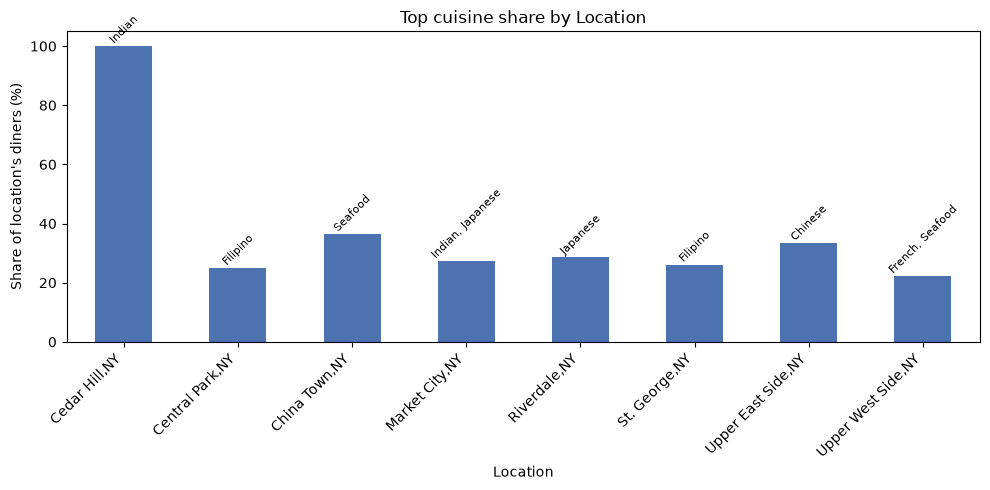

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
top_by_location.plot(x='Location', y='Top %', kind='bar', ax=ax, legend=False, color='#4C72B0')
for i, r in top_by_location.iterrows():
    ax.text(i, r['Top %'] + 1, r['Top cuisine(s)'], ha='center', fontsize=8, rotation=45)
ax.set_ylabel('Share of location\'s diners (%)')
ax.set_title('Top cuisine share by Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**By location:** every location has a distinct top cuisine except a genuine tie at Market City,NY (Indian and Japanese, 6 each). Leads are narrow everywhere — the strongest is China Town,NY with Seafood at 36.4%, and most locations sit in the 22–33% range for their top cuisine, meaning no single cuisine dominates any location outright. Cedar Hill,NY shows Indian at 100%, but n=2, so that's not a meaningful "lead," just the only two data points available.

## Cuisine popularity by Gender

In [5]:
ct_gender_counts = pd.crosstab(df['Gender'], df['Cuisines'])
ct_gender_pct = pd.crosstab(df['Gender'], df['Cuisines'], normalize='index').round(3) * 100

print('Counts (Cuisine x Gender):')
display(ct_gender_counts)
print('\nRow %% (share of each gender\'s diners choosing each cuisine):')
display(ct_gender_pct.round(1))

Counts (Cuisine x Gender):


Cuisines,Chinese,Filipino,French,Indian,Italian,Japanese,Seafood
Gender,,,,,,,
Female,14,12,16,10,12,14,4
Male,10,22,18,22,6,22,18



Row %% (share of each gender's diners choosing each cuisine):


Cuisines,Chinese,Filipino,French,Indian,Italian,Japanese,Seafood
Gender,,,,,,,
Female,17.1,14.6,19.5,12.2,14.6,17.1,4.9
Male,8.5,18.6,15.3,18.6,5.1,18.6,15.3


In [6]:
rows = []
for g in ct_gender_counts.index:
    row = ct_gender_counts.loc[g].sort_values(ascending=False)
    total = row.sum()
    top_val = row.iloc[0]
    top_cuisines = row[row == top_val].index.tolist()
    rows.append({
        'Gender': g,
        'n': total,
        'Top cuisine(s)': ', '.join(top_cuisines),
        'Top count': top_val,
        'Top %': round(top_val / total * 100, 1),
    })
top_by_gender = pd.DataFrame(rows)
top_by_gender

,Gender,n,Top cuisine(s),Top count,Top %
0,Female,82,French,16,19.5
1,Male,118,"Filipino, Indian, Japanese",22,18.6


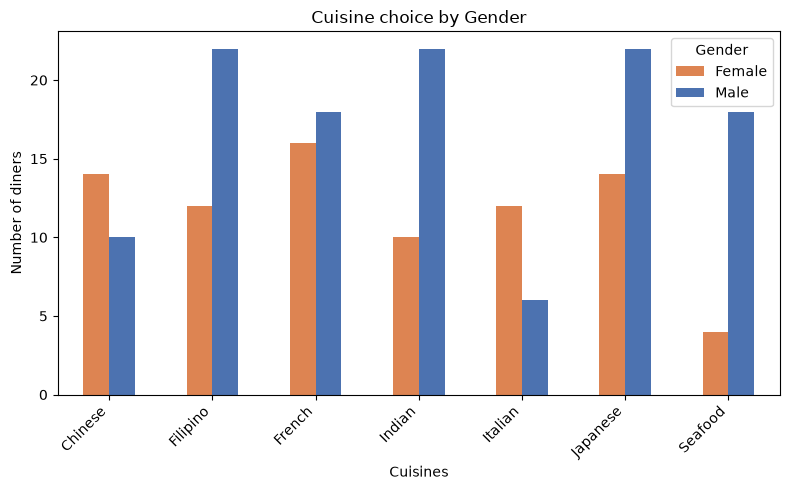

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ct_gender_counts.T.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_ylabel('Number of diners')
ax.set_title('Cuisine choice by Gender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**By gender:** Female diners lean most toward French (16 of 82, 19.5%), with Chinese close behind (14). Male diners split three ways at the top — Filipino, Indian, and Japanese are tied at 22 each (18.6% apiece) out of 118 — so there isn't a single "most popular" cuisine for men, just a top tier of three. Italian is comparatively unpopular with both genders (12 of 82 Female, 6 of 118 Male), and is proportionally the least-chosen cuisine for Male diners specifically.

## Confidence & caveats

- **Cedar Hill,NY has n=2.** Its "100% Indian" result is not a meaningful popularity signal — it's just the only two rows available for that location, and shouldn't be read as "Cedar Hill diners prefer Indian food."
- **No location has a dominant cuisine.** Top shares range 22–36% across 7 cuisines, meaning even the "most popular" choice in most locations is a plurality, not a majority — most diners at any given location chose something other than the top cuisine.
- **The Male gender breakdown has an exact three-way tie** (Filipino/Indian/Japanese at 22 each). This isn't noise to average away — it's a real structural feature of this 118-row group; reporting a single "most popular" cuisine for Male diners would misrepresent the data.
- **No statistical significance testing was run** (e.g. chi-square for independence between Cuisines and Location/Gender) since the question asked about "most popular," a descriptive framing, not "is there a significant association." A chi-square test could be a natural follow-up if that's the next question.

## Conclusion

**By location:** the top cuisine varies location to location and no location has a dominant favorite — leads are narrow (mostly 22–33% of that location's diners), with China Town,NY's lean toward Seafood (36.4%) the strongest single result. Market City,NY has a genuine tie between Indian and Japanese. Cedar Hill,NY's apparent 100% Indian preference is an artifact of only 2 data points, not a real signal.

**By gender:** Female diners most often choose French (19.5%), narrowly ahead of Chinese. Male diners don't have a single most-popular cuisine — Filipino, Indian, and Japanese are tied at 22 diners each (18.6%). Italian is the least popular cuisine overall, especially among Male diners (only 6 of 118, 5.1%).

Overall: cuisine preference is fairly dispersed across both location and gender in this dataset — no cuisine commands a clear majority anywhere, so "most popular" should be read as "leading plurality," not "broadly preferred."

## Flagged follow-ups

- A chi-square test of independence (Cuisines x Location, Cuisines x Gender) would formally test whether these popularity differences are statistically distinguishable from random variation given the small per-cell counts (many cells have single-digit counts), or whether they could just be sampling noise in a 200-row dataset.
- Popularity (demand) and satisfaction (rating) are separate questions here by design — but it could be worth checking whether the most *popular* cuisine per location/gender is also the most *highly rated* one, or whether demand and satisfaction diverge (as they did in the first-pass analysis's Food-vs-Service split for Indian and Filipino cuisine).